In [1]:
#  python -m pip install -e .
import numpy as np
from jabba import JABBA
import time

x = np.linspace(0.0, 4.0 * np.pi, 10000)
series = np.sin(x) + 0.2 * np.sin(5.0 * x)
#series = np.random.randn(10000)

model = JABBA(tol=0.05, alpha=0.25, sorting="2-norm")

st = time.time()
strings, starts = model.fit_transform(series, n_jobs=1, return_start_set=True)
reconstruction = model.inverse_transform(strings, starts)
et = time.time()

print("rumtime:", et - st)

print(strings)
print(len(reconstruction))
print(model.aggregation_backend_)

Init 1 processors.
Generate 7 symbols
Compression backend: jabba.compmem
Aggregation backend: mpi-alpha-agg:aggregate_serial
rumtime: 0.005173683166503906
[['D', 'b', 'C', 'a', 'c', 'B', 'C', 'A']]
10000
mpi-alpha-agg:aggregate_serial


In [3]:
st = time.time()
strings, starts = model.fit_transform(series, n_jobs=2, return_start_set=True)
reconstruction = model.inverse_transform(strings, starts, n_jobs=4)
et = time.time()

print("rumtime:", et - st)

print(strings)
print(len(reconstruction))
print(model.aggregation_backend_)

Partition series into 2 parts
Init 2 processors.
Generate 4 symbols
Compression backend: jabba.compmem
Aggregation backend: mpi-alpha-agg:aggregate_serial
rumtime: 0.008710384368896484
[['b', 'a', 'B', 'A'], ['b', 'a', 'B', 'A']]
10000
mpi-alpha-agg:aggregate_serial


In [4]:
st = time.time()
strings, starts = model.fit_transform(series, n_jobs=4, return_start_set=True)
reconstruction = model.inverse_transform(strings, starts, n_jobs=4)
et = time.time()

print("rumtime:", et - st)

print(strings)
print(len(reconstruction))
print(model.aggregation_backend_)

Partition series into 4 parts
Init 4 processors.
Generate 4 symbols
Compression backend: jabba.compmem
Aggregation backend: mpi-alpha-agg:aggregate_serial
rumtime: 0.009599447250366211
[['b', 'A'], ['B', 'a'], ['b', 'A'], ['B', 'a']]
10000
mpi-alpha-agg:aggregate_serial


In [5]:
st = time.time()
strings, starts = model.fit_transform(series, n_jobs=5, return_start_set=True)
reconstruction = model.inverse_transform(strings, starts, n_jobs=4)
et = time.time()

print("rumtime:", et - st)

print(strings)
print(len(reconstruction))
print(model.aggregation_backend_)

Partition series into 5 parts
Init 5 processors.
Generate 11 symbols
Compression backend: jabba.compmem
Aggregation backend: mpi-alpha-agg:aggregate_serial
rumtime: 0.009556293487548828
[['e', 'b'], ['F', 'A'], ['E', 'C'], ['B', 'd', 'a'], ['c', 'D']]
10000
mpi-alpha-agg:aggregate_serial


In [6]:
st = time.time()
strings, starts = model.fit_transform(series, n_jobs=6, return_start_set=True)
reconstruction = model.inverse_transform(strings, starts, n_jobs=4)
et = time.time()

print("rumtime:", et - st)

print(strings)
print(len(reconstruction))
print(model.aggregation_backend_)

Partition series into 6 parts
Init 6 processors.
Generate 6 symbols
Compression backend: jabba.compmem
Aggregation backend: mpi-alpha-agg:aggregate_serial
rumtime: 0.010587215423583984
[['c', 'A'], ['b', 'B'], ['a', 'C'], ['c', 'A'], ['b', 'B'], ['a', 'C']]
10000
mpi-alpha-agg:aggregate_serial


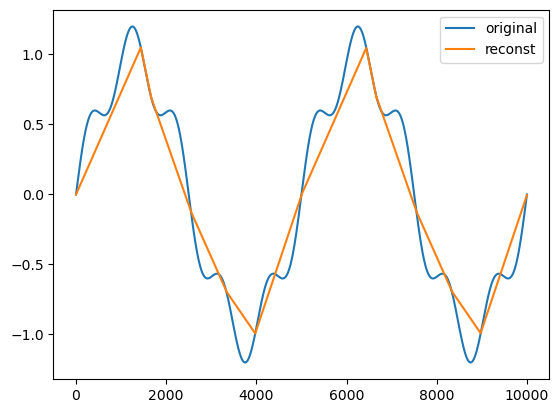

In [7]:
import matplotlib.pyplot as plt

plt.plot(series , label="original")
plt.plot(reconstruction, label="reconst")
plt.legend()